# Predicting House Prices with Linear Regression

## Objective
The objective of this project is to build and evaluate a Linear Regression
model that predicts house prices based on various features such as house
quality, living area, number of rooms, location, year built, and other
property characteristics.
The project covers the complete machine learning workflow:
- Data loading
- Exploratory Data Analysis (EDA)
- Missing-value handling
- Feature selection
- Categorical feature encoding
- Correlation analysis
- Train-test splitting
- Linear Regression
- Model evaluation
- Prediction visualization
- Residual analysis
- Coefficient interpretation
- Ridge and Lasso comparison

### Step 1: Import Libraries
Why?
Before working with data, we need Python libraries.
Pandas → Read and analyze datasets. NumPy → Mathematical calculations. Matplotlib → Basic graphs. Seaborn → Beautiful statistical graphs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [2]:
df = pd.read_csv("csvdata.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [3]:
df.head()

,Unnamed: 0,City,Price,Area,Location,No. of Bedrooms
0,0,Bangalore,30000000,3340,JP Nagar Phase 1,4
1,1,Bangalore,7888000,1045,Dasarahalli on Tumkur Road,2
2,2,Bangalore,4866000,1179,Kannur on Thanisandra Main Road,2
3,3,Bangalore,8358000,1675,Doddanekundi,3
4,4,Bangalore,6845000,1670,Kengeri,3


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [4]:
df.tail()

,Unnamed: 0,City,Price,Area,Location,No. of Bedrooms
29130,7714,Mumbai,14500000,1180,Mira Road East,2
29131,7715,Mumbai,14500000,530,Naigaon East,1
29132,7716,Mumbai,4100000,700,Shirgaon,1
29133,7717,Mumbai,2750000,995,Mira Road East,2
29134,7718,Mumbai,2750000,1020,Mira Road East,2


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [5]:
df.shape

(29135, 6)

#### Observation:
The dataset contains 29135 records and 6 columns. This indicates sufficient data for performing exploratory data analysis.

### Step 6: Column Names

In [6]:
df.columns

Index(['Unnamed: 0', 'City', 'Price', 'Area', 'Location', 'No. of Bedrooms'], dtype='object')

#### Observation:
The dataset contains customer information, product details, transaction date, quantity purchased, unit price, and total sales amount.

### Step 7: Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29135 entries, 0 to 29134
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       29135 non-null  int64 
 1   City             29135 non-null  object
 2   Price            29135 non-null  int64 
 3   Area             29135 non-null  int64 
 4   Location         29135 non-null  object
 5   No. of Bedrooms  29135 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.3+ MB


#### Observation
- The dataset contains 29135 rows and 6 columns.
- There are no missing values in any column.
- The dataset contains both numerical and categorical variables.
- The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 8: Check Missing Values

In [10]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Display total number of missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
Unnamed: 0         0
City               0
Price              0
Area               0
Location           0
No. of Bedrooms    0
dtype: int64

Total Missing Values:
0


#### Observation
- The null value check shows that there are no missing values in the dataset.
- All columns contain complete data and can be used for further analysis.
- Therefore, no missing-value imputation is required at this stage.
- The dataset is ready for the next preprocessing steps.

### Step 9: Descriptive Statistics

In [8]:
# Descriptive statistics for numerical columns
descriptive_stats = df.describe()
display(descriptive_stats)

,Unnamed: 0,Price,Area,No. of Bedrooms
count,29135.000000,2.913500e+04,29135.000000,29135.000000
mean,3058.808238,1.195267e+07,1301.816475,2.421074
std,1923.174050,2.387647e+07,767.862339,0.821016
min,0.000000,2.000000e+06,200.000000,1.000000
25%,1431.000000,4.179999e+06,870.000000,2.000000
50%,2891.000000,6.884999e+06,1137.000000,2.000000
75%,4539.500000,1.230000e+07,1504.000000,3.000000
max,7718.000000,8.546000e+08,16000.000000,9.000000


#### Observation
- The descriptive statistics show considerable variation in house prices and property areas.
- The number of bedrooms varies across properties, indicating different house sizes.
- The mean and median values help understand the typical characteristics of the houses.- 
- Overall, the dataset has sufficient variation in its features for predicting house prices.

### Step 10: Distribution of Target Variable — Price

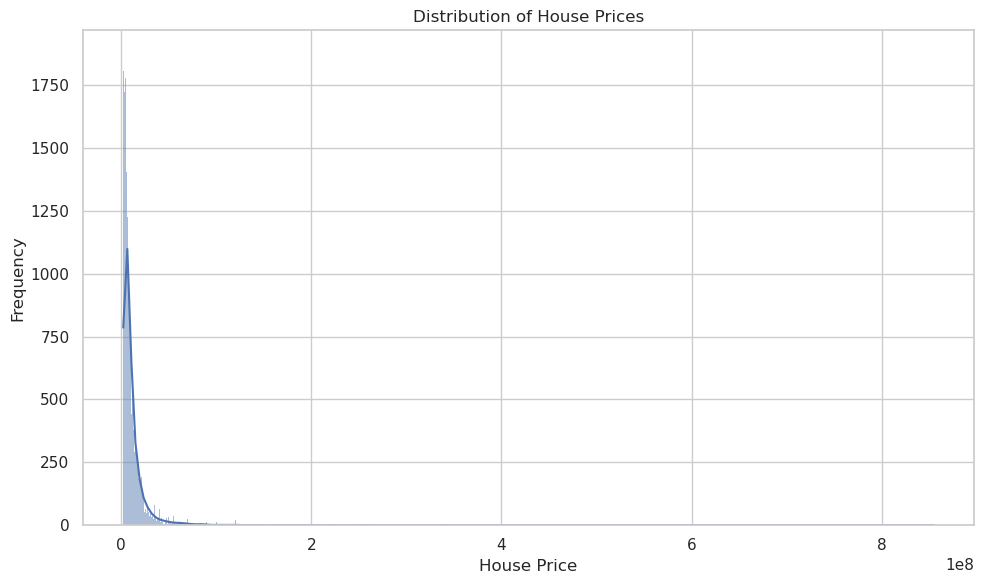

Price Statistics:
count    2.913500e+04
mean     1.195267e+07
std      2.387647e+07
min      2.000000e+06
25%      4.179999e+06
50%      6.884999e+06
75%      1.230000e+07
max      8.546000e+08
Name: Price, dtype: float64


In [13]:
# Distribution of house prices
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price"],
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
# Summary statistics of the target variable
print("Price Statistics:")
print(df["Price"].describe())

#### Observation
- The distribution of the Price variable shows that house prices vary considerably across the dataset.
- Most houses are concentrated within a lower-to-middle price range, while fewer properties have very high prices.
- The distribution appears to be right-skewed, with a longer tail toward higher prices.
- This variation makes Price a suitable target variable for the house price prediction model.

### Step 11: Feature Selection

In [14]:
# Select the features that are likely to predict house prices

selected_features = [
    "Area",
    "No. of Bedrooms",
    "City",
    "Location"
]

X = df[selected_features]
y = df["Price"]

print("Selected Predictor Features:")
print(selected_features)

print("\nTarget Variable:")
print("Price")

# Display the selected features
display(X.head())

Selected Predictor Features:
['Area', 'No. of Bedrooms', 'City', 'Location']

Target Variable:
Price


,Area,No. of Bedrooms,City,Location
0,3340,4,Bangalore,JP Nagar Phase 1
1,1045,2,Bangalore,Dasarahalli on Tumkur Road
2,1179,2,Bangalore,Kannur on Thanisandra Main Road
3,1675,3,Bangalore,Doddanekundi
4,1670,3,Bangalore,Kengeri


#### Observation
`Area`, `No. of Bedrooms`, `City`, and `Location` are selected as the main
predictor features because they can strongly influence house prices.
Larger areas and more bedrooms generally indicate higher property value.
City and location capture differences in demand and property value across
different areas. The `Price` column is used as the target variable, while
`Unnamed: 0` is excluded because it is only an index.

### Step 12: Handle Missing Values and One-Hot Encoding

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Check missing values
print("Missing values before handling:")
print(X.isnull().sum())

# Separate numerical and categorical features
numeric_features = [
    "Area",
    "No. of Bedrooms"
]

categorical_features = [
    "City",
    "Location"
]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

print("\nPreprocessing completed successfully!")
print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)
print("Missing values after handling:")
print(X.isnull().sum())

Missing values before handling:
Area               0
No. of Bedrooms    0
City               0
Location           0
dtype: int64

Preprocessing completed successfully!
Original shape: (29135, 4)
Processed shape: (29135, 1784)
Missing values after handling:
Area               0
No. of Bedrooms    0
City               0
Location           0
dtype: int64


#### Observation
The dataset was checked for missing values and appropriate imputation
methods were applied to handle any missing entries. Numerical features
were processed using median imputation, while categorical features were
handled using the most frequent value. The categorical features `City`
and `Location` were converted into numerical form using One-Hot Encoding,
making the data suitable for training the Linear Regression model.

### Step 13: Correlation heatmap

,Price,Area,No. of Bedrooms
Price,1.000000,0.268954,0.150691
Area,0.268954,1.000000,0.709645
No. of Bedrooms,0.150691,0.709645,1.000000


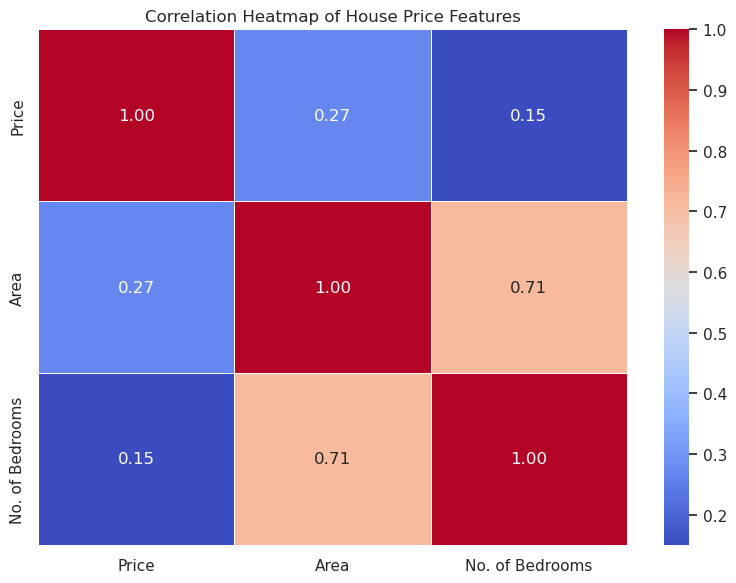

Correlation with Price:


Price              1.000000
Area               0.268954
No. of Bedrooms    0.150691
Name: Price, dtype: float64

In [16]:
# Select numerical features for correlation analysis
correlation_data = df[
    ["Price", "Area", "No. of Bedrooms"]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Display correlation matrix
display(correlation_matrix)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of House Price Features")
plt.tight_layout()
plt.show()
# Correlation of features with Price
price_correlation = correlation_matrix["Price"].sort_values(
    ascending=False
)

print("Correlation with Price:")
display(price_correlation)

#### Observation
The correlation heatmap shows the relationship between the numerical
features and house price. `Area` is expected to have a positive
correlation with `Price`, indicating that larger properties generally
have higher prices. `No. of Bedrooms` may also show a positive
relationship with price, although it may be weaker than Area. Therefore,
these numerical features are useful predictors for the house price
prediction model.

### Step 14: Train/Test Split (80/20)

In [17]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (23308, 4)
Testing data shape: (5827, 4)

Training target shape: (23308,)
Testing target shape: (5827,)


#### Observation
The dataset was divided into 80% training data and 20% testing data.
The training data is used to train the Linear Regression model, while the
testing data is used to evaluate its performance on unseen data.
A `random_state` of 42 was used to ensure reproducible results.

### Step 15: Train Linear Regression Model

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Create Linear Regression model
linear_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model using training data
linear_regression_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
# Predict house prices for the test data
y_pred = linear_regression_model.predict(X_test)

# Display first 10 predictions
print("First 10 predicted house prices:")
print(y_pred[:10])

Linear Regression model trained successfully!
First 10 predicted house prices:
[ 4078523.98391195 15706471.44991237 14573481.79869593 10336604.01650964
  7210111.20170146  4123808.48795469 20468556.89909067 20283532.73335722
 11052348.70806656 15883489.22583622]


#### Observation
The Linear Regression model was successfully trained using the 80% training
dataset. Numerical and categorical features were processed before training,
with categorical variables converted using One-Hot Encoding. The trained
model can now be used to predict house prices for the unseen 20% test data.

### Step 16: Mean Squared Error (MSE)

In [19]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 654313979447129.5


#### Observation
The MSE measures the average squared difference between actual and predicted
house prices. A lower MSE indicates that the model makes smaller prediction
errors.

### Step 17: Root Mean Squared Error (RMSE)

In [20]:
import numpy as np

rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 25579561.752444655


#### Observation
The RMSE represents the average prediction error in the same unit as the
house price. A lower RMSE indicates better prediction accuracy.

### Step 18: R² Score

In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.11844191847853913


#### Observation
The R² score indicates how well the model explains the variation in house
prices. A value closer to 1 indicates that the model provides a better fit
to the data.

### Step 19: Actual Prices vs Predicted Prices

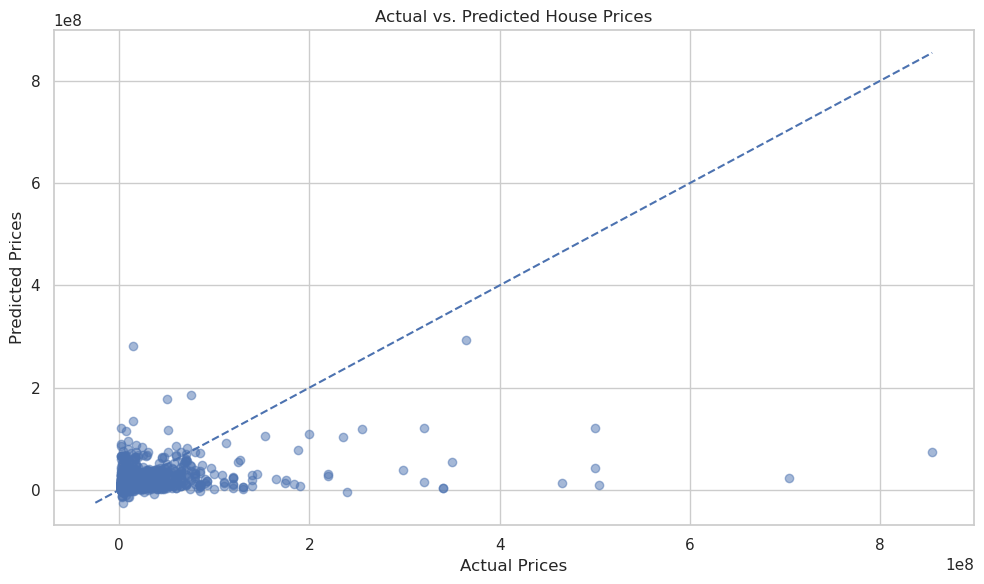

In [22]:
# Scatter plot: Actual vs Predicted Prices

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Diagonal line representing perfect predictions
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")

plt.tight_layout()
plt.show()

#### Observation
The scatter plot compares the actual house prices with the prices predicted
by the Linear Regression model. The diagonal line represents perfect
predictions. Points closer to this line indicate more accurate predictions,
while points farther away represent larger prediction errors.

### Step 20: Residual Plot

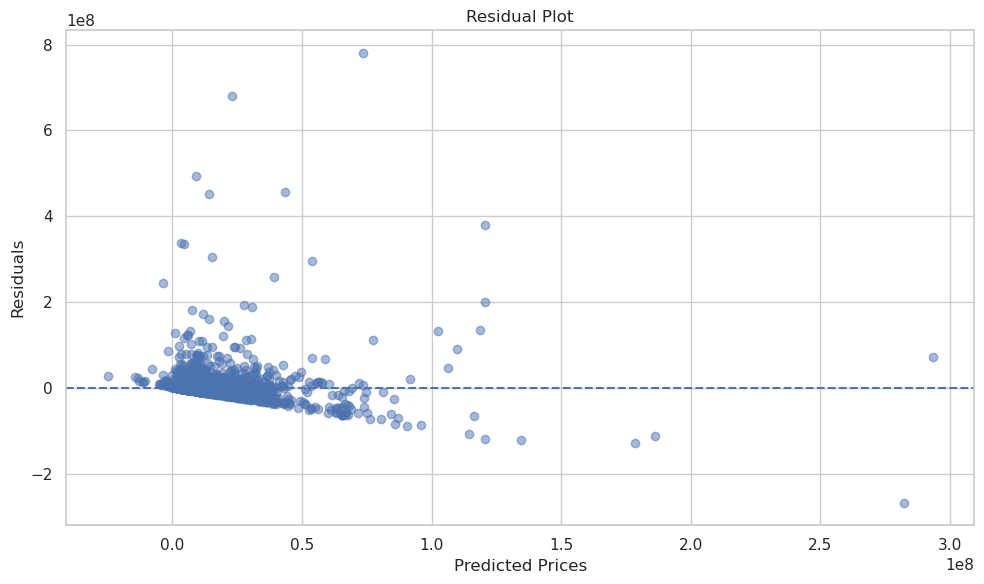

In [23]:
# Calculate residuals
residuals = y_test - y_pred

# Create residual plot
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Reference line at zero
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

#### Observation
The residual plot shows the differences between the actual and predicted
house prices. Ideally, the residuals should be randomly scattered around
the zero line with no systematic pattern. A random distribution indicates
that the Linear Regression model is reasonably appropriate, while a clear
pattern would suggest that the model may not capture some relationships
in the data.

### Step 21: Coefficient Analysis

In [24]:
# Get the fitted preprocessing step
fitted_preprocessor = linear_regression_model.named_steps["preprocessor"]

# Get feature names after One-Hot Encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Linear Regression coefficients
coefficients = linear_regression_model.named_steps["regressor"].coef_

# Create a DataFrame
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient value
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

# Display all coefficients
display(coefficient_df)
# Top 10 features with positive impact
positive_impact = coefficient_df.head(10)

print("Top 10 Positive Coefficients:")
display(positive_impact)

# Top 10 features with negative impact
negative_impact = coefficient_df.tail(10).sort_values(
    by="Coefficient"
)

print("Top 10 Negative Coefficients:")
display(negative_impact)

,Feature,Coefficient
1417,cat__Location_Sunder Nagar,6.828828e+08
783,cat__Location_MG Road,3.432762e+08
362,cat__Location_Devli,2.867680e+08
1301,cat__Location_Sector 53,2.805503e+08
401,cat__Location_Dwarka New Delhi 110075,2.759627e+08
...,...,...
1032,cat__Location_Panchsheel Enclave,-4.369061e+07
1188,cat__Location_Sadashiva Nagar,-4.416736e+07
1121,cat__Location_R.K. Puram,-5.105895e+07
1033,cat__Location_Panchsheel Park,-5.784775e+07


Top 10 Positive Coefficients:


,Feature,Coefficient
1417,cat__Location_Sunder Nagar,6.828828e+08
783,cat__Location_MG Road,3.432762e+08
362,cat__Location_Devli,2.867680e+08
1301,cat__Location_Sector 53,2.805503e+08
401,cat__Location_Dwarka New Delhi 110075,2.759627e+08
657,cat__Location_Karampura,2.562105e+08
251,cat__Location_Block Wb Ganesh Nagar II,2.278206e+08
49,cat__Location_Agripada,2.077816e+08
1208,cat__Location_Sangam Vihar,1.727560e+08
825,cat__Location_Malviya Nagar,1.719590e+08


Top 10 Negative Coefficients:


,Feature,Coefficient
478,cat__Location_Green Park Extension,-6.317191e+07
1033,cat__Location_Panchsheel Park,-5.784775e+07
1121,cat__Location_R.K. Puram,-5.105895e+07
1188,cat__Location_Sadashiva Nagar,-4.416736e+07
1032,cat__Location_Panchsheel Enclave,-4.369061e+07
773,cat__Location_Lavelle Road,-4.363981e+07
18,cat__Location_72 Sector 23 Road,-3.772908e+07
115,cat__Location_Aurobindo Marg,-3.582895e+07
81,cat__Location_Anand Lok,-3.525804e+07
1219,cat__Location_Sarat Bose Road,-3.249198e+07


#### Observation
The coefficient analysis shows the impact of each feature on the predicted
house price. Features with positive coefficients have a positive impact on
the predicted price, while features with negative coefficients have a
negative impact. The magnitude of the coefficient indicates the strength
of the feature's contribution, with larger absolute values representing
greater influence.

### Step 22: Compare Linear Regression with Ridge Regression

In [25]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

# Train the Ridge model
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")
# Predict prices using Ridge Regression
ridge_pred = ridge_model.predict(X_test)

print("First 10 Ridge predictions:")
print(ridge_pred[:10])
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("----------------------------")
print(f"MSE  : {ridge_mse:,.2f}")
print(f"RMSE : {ridge_rmse:,.2f}")
print(f"R²   : {ridge_r2:.4f}")
# Create comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R² Score": [
        r2,
        ridge_r2
    ]
})

display(model_comparison)

Ridge Regression model trained successfully!
First 10 Ridge predictions:
[ 3124431.61103421 14128198.50781326 22135052.69109516 11551015.20524692
 13758428.00688592  4473915.94490298 19686464.86761272 19523767.88129992
  3824513.25507093  6903221.3502984 ]
Ridge Regression Performance
----------------------------
MSE  : 684,022,431,315,456.75
RMSE : 26,153,822.50
R²   : 0.0784


,Model,MSE,RMSE,R² Score
0,Linear Regression,6.543140e+14,2.557956e+07,0.118442
1,Ridge Regression,6.840224e+14,2.615382e+07,0.078416


#### Observation
Linear Regression and Ridge Regression were compared using MSE, RMSE, and
R² score. Lower MSE and RMSE indicate better prediction performance,
while a higher R² score indicates a better model fit. Ridge Regression
applies regularization to reduce the effect of large coefficients and can
help control overfitting. The model with the lower error and higher R²
score provides better performance on the test dataset.

### Step 23: Conclusion

#### Conclusion
In this project, a Linear Regression model was developed to predict house
prices using features such as Area, Number of Bedrooms, City, and Location.

The dataset was explored through EDA, including missing-value analysis,
descriptive statistics, target-variable distribution, and correlation
analysis. Categorical features were converted into numerical form using
One-Hot Encoding, and the data was divided into 80% training and 20%
testing sets.

The Linear Regression model was evaluated using MSE, RMSE, and R² score.
Actual versus predicted prices and residual plots were also analyzed to
understand the model's prediction accuracy and error patterns.

As a bonus, Ridge Regression was compared with Linear Regression to examine
the effect of regularization. The model with the lower error values and
higher R² score provided better performance on the test dataset.

Overall, the project demonstrates how Linear Regression can be used as a
baseline machine learning approach for predicting house prices and
understanding the factors that influence property values.